In [18]:
import os
import pandas as pd
import numpy as np
import mlflow

from sklearn.model_selection import train_test_split

In [19]:
PROJECT_ROOT = os.path.abspath("..")
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "loan_approval_dataset.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,rejected


In [20]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [21]:
target_col = "loan_status"
print(df[target_col].unique())

print(df[target_col].value_counts(dropna=False))

['approved' 'rejected']
loan_status
approved    2656
rejected    1613
Name: count, dtype: int64


In [22]:

df[target_col] = df[target_col].map({"approved": 1, "rejected": 0})

df[target_col].value_counts(dropna=False)

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [23]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [27]:
drop_cols = [col for col in ["loan_id"] if col in df.columns]
df = df.drop(columns=drop_cols)

## Model Training

In [28]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [29]:
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical: ['education', 'self_employed']


In [30]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(2988, 11) (640, 11) (641, 11)


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [33]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_val_processed.shape, X_test_processed.shape)

(2988, 13) (640, 13) (641, 13)


In [34]:
import joblib

ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

preprocessor_path = os.path.join(ARTIFACTS_DIR, "preprocessor.joblib")
joblib.dump(preprocessor, preprocessor_path)

print("Saved preprocessor to:", preprocessor_path)

Saved preprocessor to: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/artifacts/preprocessor.joblib


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [36]:
def evaluate_model(model, X_data, y_true, threshold=0.5):
    y_prob = model.predict_proba(X_data)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }
    return metrics, y_pred, y_prob

In [37]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_processed, y_train)

lr_val_metrics, _, _ = evaluate_model(lr_model, X_val_processed, y_val)
lr_test_metrics, _, _ = evaluate_model(lr_model, X_test_processed, y_test)

print("LR Validation Metrics:", lr_val_metrics)
print("LR Test Metrics:", lr_test_metrics)

LR Validation Metrics: {'accuracy': 0.8234375, 'precision': 0.8051391862955032, 'recall': 0.9447236180904522, 'f1': 0.869364161849711, 'roc_auc': 0.9004734415881058}
LR Test Metrics: {'accuracy': 0.7940717628705148, 'precision': 0.789587852494577, 'recall': 0.9122807017543859, 'f1': 0.8465116279069768, 'roc_auc': 0.8769133577746018}


In [38]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("loan_approval_phase3")

with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)

    for k, v in lr_val_metrics.items():
        mlflow.log_metric(f"val_{k}", v)

    for k, v in lr_test_metrics.items():
        mlflow.log_metric(f"test_{k}", v)

/Users/pranavsrinivasvenkatesh/anaconda3/envs/multimodal_research/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/04 22:07:14 INFO mlflow.tracking.fluent: Experiment with name 'loan_approval_phase3' does not exist. Creating a new experiment.


In [39]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

rf_val_metrics, _, _ = evaluate_model(rf_model, X_val_processed, y_val)
rf_test_metrics, _, _ = evaluate_model(rf_model, X_test_processed, y_test)

print("RF Validation Metrics:", rf_val_metrics)
print("RF Test Metrics:", rf_test_metrics)

RF Validation Metrics: {'accuracy': 0.98125, 'precision': 0.9873737373737373, 'recall': 0.9824120603015075, 'f1': 0.9848866498740554, 'roc_auc': 0.999107105776818}
RF Test Metrics: {'accuracy': 0.9765990639625585, 'precision': 0.9824120603015075, 'recall': 0.9799498746867168, 'f1': 0.9811794228356336, 'roc_auc': 0.9949460427929327}


In [40]:
with mlflow.start_run(run_name="random_forest_baseline"):
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 8)

    for k, v in rf_val_metrics.items():
        mlflow.log_metric(f"val_{k}", v)

    for k, v in rf_test_metrics.items():
        mlflow.log_metric(f"test_{k}", v)

In [41]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

xgb_val_metrics, _, _ = evaluate_model(xgb_model, X_val_processed, y_val)
xgb_test_metrics, _, _ = evaluate_model(xgb_model, X_test_processed, y_test)

print("XGB Validation Metrics:", xgb_val_metrics)
print("XGB Test Metrics:", xgb_test_metrics)

XGB Validation Metrics: {'accuracy': 0.9875, 'precision': 0.9924242424242424, 'recall': 0.9874371859296482, 'f1': 0.9899244332493703, 'roc_auc': 0.999283608123261}
XGB Test Metrics: {'accuracy': 0.982839313572543, 'precision': 0.985, 'recall': 0.9874686716791979, 'f1': 0.986232790988736, 'roc_auc': 0.9981979742745293}


In [42]:
with mlflow.start_run(run_name="xgboost_model"):
    mlflow.log_param("model_type", "XGBClassifier")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)

    for k, v in xgb_val_metrics.items():
        mlflow.log_metric(f"val_{k}", v)

    for k, v in xgb_test_metrics.items():
        mlflow.log_metric(f"test_{k}", v)

In [43]:
comparison_df = pd.DataFrame([
    {"model": "LogisticRegression", **lr_test_metrics},
    {"model": "RandomForest", **rf_test_metrics},
    {"model": "XGBoost", **xgb_test_metrics},
])

comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.982839,0.985000,0.987469,0.986233,0.998198
1,RandomForest,0.976599,0.982412,0.979950,0.981179,0.994946
0,LogisticRegression,0.794072,0.789588,0.912281,0.846512,0.876913


In [44]:
best_model_path = os.path.join(ARTIFACTS_DIR, "best_model.joblib")
joblib.dump(xgb_model, best_model_path)

print("Best model saved to:", best_model_path)

Best model saved to: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/artifacts/best_model.joblib


In [45]:
comparison_path = os.path.join(ARTIFACTS_DIR, "model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

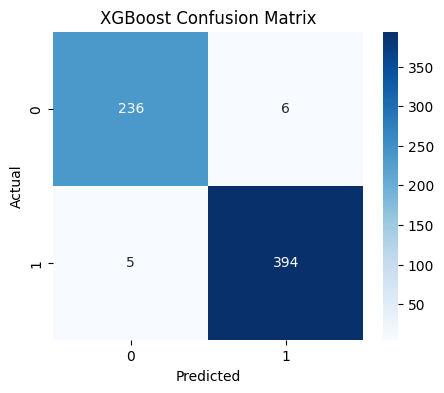

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

xgb_test_metrics, xgb_test_pred, xgb_test_prob = evaluate_model(xgb_model, X_test_processed, y_test)

cm = confusion_matrix(y_test, xgb_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()